In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

os.makedirs('../figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [8]:
with open('../results/results.json') as f:
    store = json.load(f)

print('Meta:', store['meta'])
print('Datasets available:', list(store['datasets'].keys()))

Meta: {'n_splits': 10, 'test_size': 0.2, 'seed': 0, 't_grid_points': 200, 'tabpfn_train_max': 1000, 'tabpfn_batch': 164}
Datasets available: ['whas500', 'gbsg', 'metabric']


In [9]:
# Flatten into a tidy DataFrame
records = []
for ds, methods in store['datasets'].items():
    for method, splits in methods.items():
        for s in splits:
            records.append({'dataset': ds, 'method': method,
                            'C-index': s['ci'], 'IBS': s['ibs']})

df = pd.DataFrame(records)
datasets = list(store['datasets'].keys())
methods  = df['method'].unique().tolist()
print(df.groupby(['dataset', 'method'])[['C-index', 'IBS']].mean().round(3))

                    C-index    IBS
dataset  method                   
gbsg     cox          0.661  0.191
         fsa          0.656  0.277
         lognormal    0.669  0.189
         rsf          0.677  0.186
         weibull      0.662  0.192
metabric cox          0.643  0.185
         fsa          0.619  0.229
         lognormal    0.646  0.187
         rsf          0.624  0.190
         weibull      0.643  0.185
whas500  cox          0.768  0.168
         fsa          0.699  0.311
         lognormal    0.767  0.171
         rsf          0.745  0.162
         weibull      0.769  0.169


In [10]:
METHOD_LABELS = {
    'fsa':       'FSA (ours)',
    'cox':       'Cox PH',
    'weibull':   'Weibull AFT',
    'lognormal': 'LogNormal AFT',
    'rsf':       'RSF',
}
PALETTE = dict(zip(
    METHOD_LABELS.keys(),
    ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
))

df['Method'] = df['method'].map(METHOD_LABELS)
method_order = [METHOD_LABELS[m] for m in ['fsa', 'cox', 'weibull', 'lognormal', 'rsf']]
color_order  = [PALETTE[m] for m in ['fsa', 'cox', 'weibull', 'lognormal', 'rsf']]

/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_order, rotation=35, ha='right', fontsize=9)
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

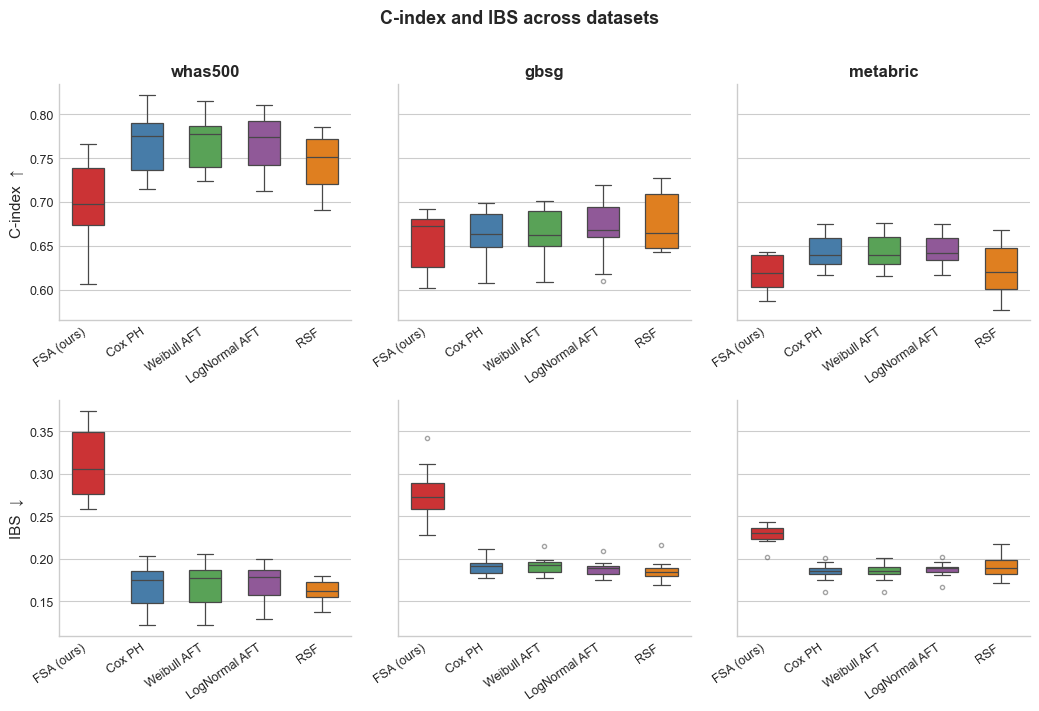

In [11]:
n_ds = len(datasets)
fig, axes = plt.subplots(2, n_ds, figsize=(3.5 * n_ds, 7), sharey='row')
if n_ds == 1:
    axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]
    for row, (metric, better) in enumerate([('C-index', '↑'), ('IBS', '↓')]):
        ax = axes[row, col]
        sns.boxplot(
            data=sub, x='Method', y=metric, order=method_order,
            palette=color_order, width=0.55, linewidth=0.9,
            flierprops=dict(marker='o', markersize=3, alpha=0.5),
            ax=ax
        )
        if row == 0:
            ax.set_title(ds, fontsize=12, fontweight='bold', pad=6)
        ax.set_xlabel('')
        ax.set_xticklabels(method_order, rotation=35, ha='right', fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', labelsize=9)
        if col == 0:
            ax.set_ylabel(f'{metric}  {better}', fontsize=11)
        else:
            ax.set_ylabel('')
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('C-index and IBS across datasets', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/results_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/results_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Summary table: mean ± std
rows = []
for ds in datasets:
    for method in ['fsa', 'cox', 'weibull', 'lognormal', 'rsf']:
        sub = df[(df['dataset'] == ds) & (df['method'] == method)]
        rows.append({
            'Dataset': ds, 'Method': METHOD_LABELS[method],
            'C-index': f"{sub['C-index'].mean():.3f} ± {sub['C-index'].std():.3f}",
            'IBS':     f"{sub['IBS'].mean():.3f} ± {sub['IBS'].std():.3f}",
        })

table = pd.DataFrame(rows).set_index(['Dataset', 'Method'])
display(table)
print('\nLaTeX:')
print(table.to_latex())

C-index            IBS
Dataset  Method                                     
whas500  FSA (ours)     0.699 ± 0.048  0.311 ± 0.043
         Cox PH         0.768 ± 0.037  0.168 ± 0.026
         Weibull AFT    0.769 ± 0.032  0.169 ± 0.026
         LogNormal AFT  0.767 ± 0.032  0.171 ± 0.022
         RSF            0.745 ± 0.032  0.162 ± 0.014
gbsg     FSA (ours)     0.656 ± 0.033  0.277 ± 0.033
         Cox PH         0.661 ± 0.031  0.191 ± 0.010
         Weibull AFT    0.662 ± 0.032  0.192 ± 0.010
         LogNormal AFT  0.669 ± 0.035  0.189 ± 0.009
         RSF            0.677 ± 0.034  0.186 ± 0.013
metabric FSA (ours)     0.619 ± 0.021  0.229 ± 0.012
         Cox PH         0.643 ± 0.021  0.185 ± 0.011
         Weibull AFT    0.643 ± 0.021  0.185 ± 0.011
         LogNormal AFT  0.646 ± 0.018  0.187 ± 0.010
         RSF            0.624 ± 0.030  0.190 ± 0.014


LaTeX:
\begin{tabular}{llll}
\toprule
 &  & C-index & IBS \\
Dataset & Method &  &  \\
\midrule
\multirow[t]{5}{*}{whas500} & FSA (ours) & 0.699 ± 0.048 & 0.311 ± 0.043 \\
 & Cox PH & 0.768 ± 0.037 & 0.168 ± 0.026 \\
 & Weibull AFT & 0.769 ± 0.032 & 0.169 ± 0.026 \\
 & LogNormal AFT & 0.767 ± 0.032 & 0.171 ± 0.022 \\
 & RSF & 0.745 ± 0.032 & 0.162 ± 0.014 \\
\cline{1-4}
\multirow[t]{5}{*}{gbsg} & FSA (ours) & 0.656 ± 0.033 & 0.277 ± 0.033 \\
 & Cox PH & 0.661 ± 0.031 & 0.191 ± 0.010 \\
 & Weibull AFT & 0.662 ± 0.032 & 0.192 ± 0.010 \\
 & LogNormal AFT & 0.669 ± 0.035 & 0.189 ± 0.009 \\
 & RSF & 0.677 ± 0.034 & 0.186 ± 0.013 \\
\cline{1-4}
\multirow[t]{5}{*}{metabric} & FSA (ours) & 0.619 ± 0.021 & 0.229 ± 0.012 \\
 & Cox PH & 0.643 ± 0.021 & 0.185 ± 0.011 \\
 & Weibull AFT & 0.643 ± 0.021 & 0.185 ± 0.011 \\
 & LogNormal AFT & 0.646 ± 0.018 & 0.187 ± 0.010 \\
 & RSF & 0.624 ± 0.030 & 0.190 ± 0.014 \\
\cline{1-4}
\bottomrule
\end{tabular}

